In [1]:
import pandas as pd
import numpy as np

# Semilla para resultados reproducibles
np.random.seed(42)

productos = ['Leche', 'Pan', 'Refresco', 'Jabón', 'Arroz', 'Aceite', 'Frijol', 'Agua']
categorias = {'Leche':'Lácteos','Pan':'Panadería','Refresco':'Bebidas',
              'Jabón':'Limpieza','Arroz':'Granos','Aceite':'Cocina',
              'Frijol':'Granos','Agua':'Bebidas'}
meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio']

rows = []
for _ in range(200):
    p = np.random.choice(productos)
    rows.append({
        'producto': p,
        'categoria': categorias[p],
        'mes': np.random.choice(meses),
        'cantidad': np.random.randint(1, 20),
        'precio_unitario': round(np.random.uniform(10, 80), 2)
    })

df = pd.DataFrame(rows)
df['ingreso'] = df['cantidad'] * df['precio_unitario']
df.head(10)

,producto,categoria,mes,cantidad,precio_unitario,ingreso
0,Frijol,Granos,Abril,15,61.24,918.60
1,Arroz,Granos,Mayo,7,41.21,288.47
2,Frijol,Granos,Marzo,11,70.63,776.93
3,Jabón,Limpieza,Marzo,2,60.54,121.08
4,Aceite,Cocina,Junio,2,22.73,45.46
5,Arroz,Granos,Enero,12,52.82,633.84
6,Arroz,Granos,Abril,17,46.73,794.41
7,Frijol,Granos,Febrero,16,26.29,420.64
8,Aceite,Cocina,Junio,19,36.77,698.63
9,Jabón,Limpieza,Enero,3,70.20,210.60


In [2]:
# Forma del dataset y tipos de datos
print("Filas y columnas:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nResumen estadístico:")
df.describe()

Filas y columnas: (200, 6)

Tipos de datos:
producto            object
categoria           object
mes                 object
cantidad             int64
precio_unitario    float64
ingreso            float64
dtype: object

Resumen estadístico:


,cantidad,precio_unitario,ingreso
count,200.000000,200.000000,200.000000
mean,9.635000,45.181200,453.688700
std,5.880021,20.796114,372.989749
min,1.000000,11.090000,11.090000
25%,4.000000,26.597500,132.862500
50%,9.000000,45.165000,339.360000
75%,15.000000,62.992500,779.840000
max,19.000000,79.740000,1479.150000


In [3]:
# Ingreso total
print("Ingreso total:", df['ingreso'].sum().round(2))

# Producto más vendido (por cantidad)
print("\nTop 3 productos por cantidad vendida:")
print(df.groupby('producto')['cantidad'].sum().sort_values(ascending=False).head(3))

# Categoría con más ingresos
print("\nIngresos por categoría:")
print(df.groupby('categoria')['ingreso'].sum().round(2).sort_values(ascending=False))

# Mes con más ventas
print("\nIngresos por mes:")
print(df.groupby('mes')['ingreso'].sum().round(2).sort_values(ascending=False))

Ingreso total: 90737.74

Top 3 productos por cantidad vendida:
producto
Frijol    283
Leche     269
Pan       269
Name: cantidad, dtype: int64

Ingresos por categoría:
categoria
Granos       23953.55
Bebidas      20076.30
Lácteos      12649.64
Limpieza     12059.60
Panadería    11653.09
Cocina       10345.56
Name: ingreso, dtype: float64

Ingresos por mes:
mes
Enero      18807.46
Marzo      17150.69
Febrero    16691.86
Mayo       15210.48
Junio      11736.13
Abril      11141.12
Name: ingreso, dtype: float64


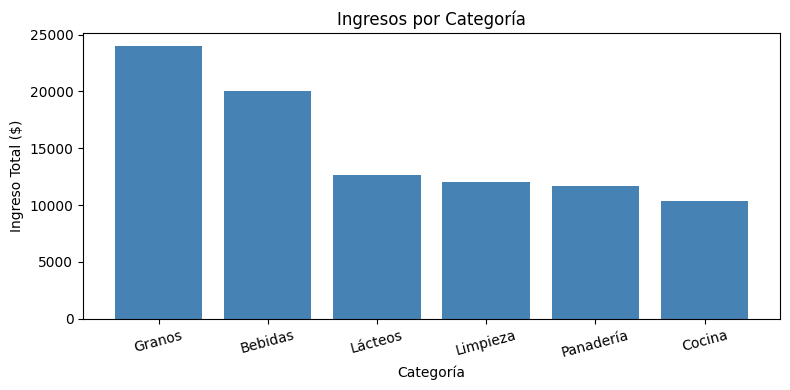

In [4]:
import matplotlib.pyplot as plt

# Ingresos por categoría
cat_ingresos = df.groupby('categoria')['ingreso'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
plt.bar(cat_ingresos.index, cat_ingresos.values, color='steelblue')
plt.title('Ingresos por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Ingreso Total ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [5]:
# Crear resumen por categoría y por mes
resumen_categoria = df.groupby('categoria').agg(
    total_cantidad=('cantidad','sum'),
    ingreso_total=('ingreso','sum')
).round(2).reset_index()

resumen_mes = df.groupby('mes').agg(
    total_cantidad=('cantidad','sum'),
    ingreso_total=('ingreso','sum')
).round(2).reset_index()

# Exportar a Excel con dos hojas
with pd.ExcelWriter('resumen_ventas.xlsx') as writer:
    resumen_categoria.to_excel(writer, sheet_name='Por Categoría', index=False)
    resumen_mes.to_excel(writer, sheet_name='Por Mes', index=False)

print("Archivo exportado correctamente")

Archivo exportado correctamente
